# Projet

## Importation des bibliothèques

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import glob
import time

## Class

In [2]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path="C:/Users/lucas/OneDrive/Documents/DTU/datasets1/02516/hotdog_nothotdog/"):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y

## Config

In [3]:
size = 128
train_transform = transforms.Compose([
    transforms.Resize((size, size)), 
    transforms.ToTensor()
])
test_transform = transforms.Compose([
    transforms.Resize((size, size)), 
    transforms.ToTensor()
])

batch_size = 64
trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)  # num_workers=0 pour éviter les problèmes
testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

## Debug (optionnel)

In [4]:
# Debug du dataset
print(f"Nombre d'images d'entraînement: {len(trainset)}")
print(f"Classes détectées: {trainset.name_to_label}")

# Récupération et affichage des images
images, labels = next(iter(train_loader))
print(f"Shape du batch: {images.shape}")
print(f"Range des valeurs: [{images.min():.3f}, {images.max():.3f}]")

Nombre d'images d'entraînement: 2047
Classes détectées: {'hotdog': 0, 'nothotdog': 1}
Shape du batch: torch.Size([64, 3, 128, 128])
Range des valeurs: [0.000, 1.000]


## Affichage 1

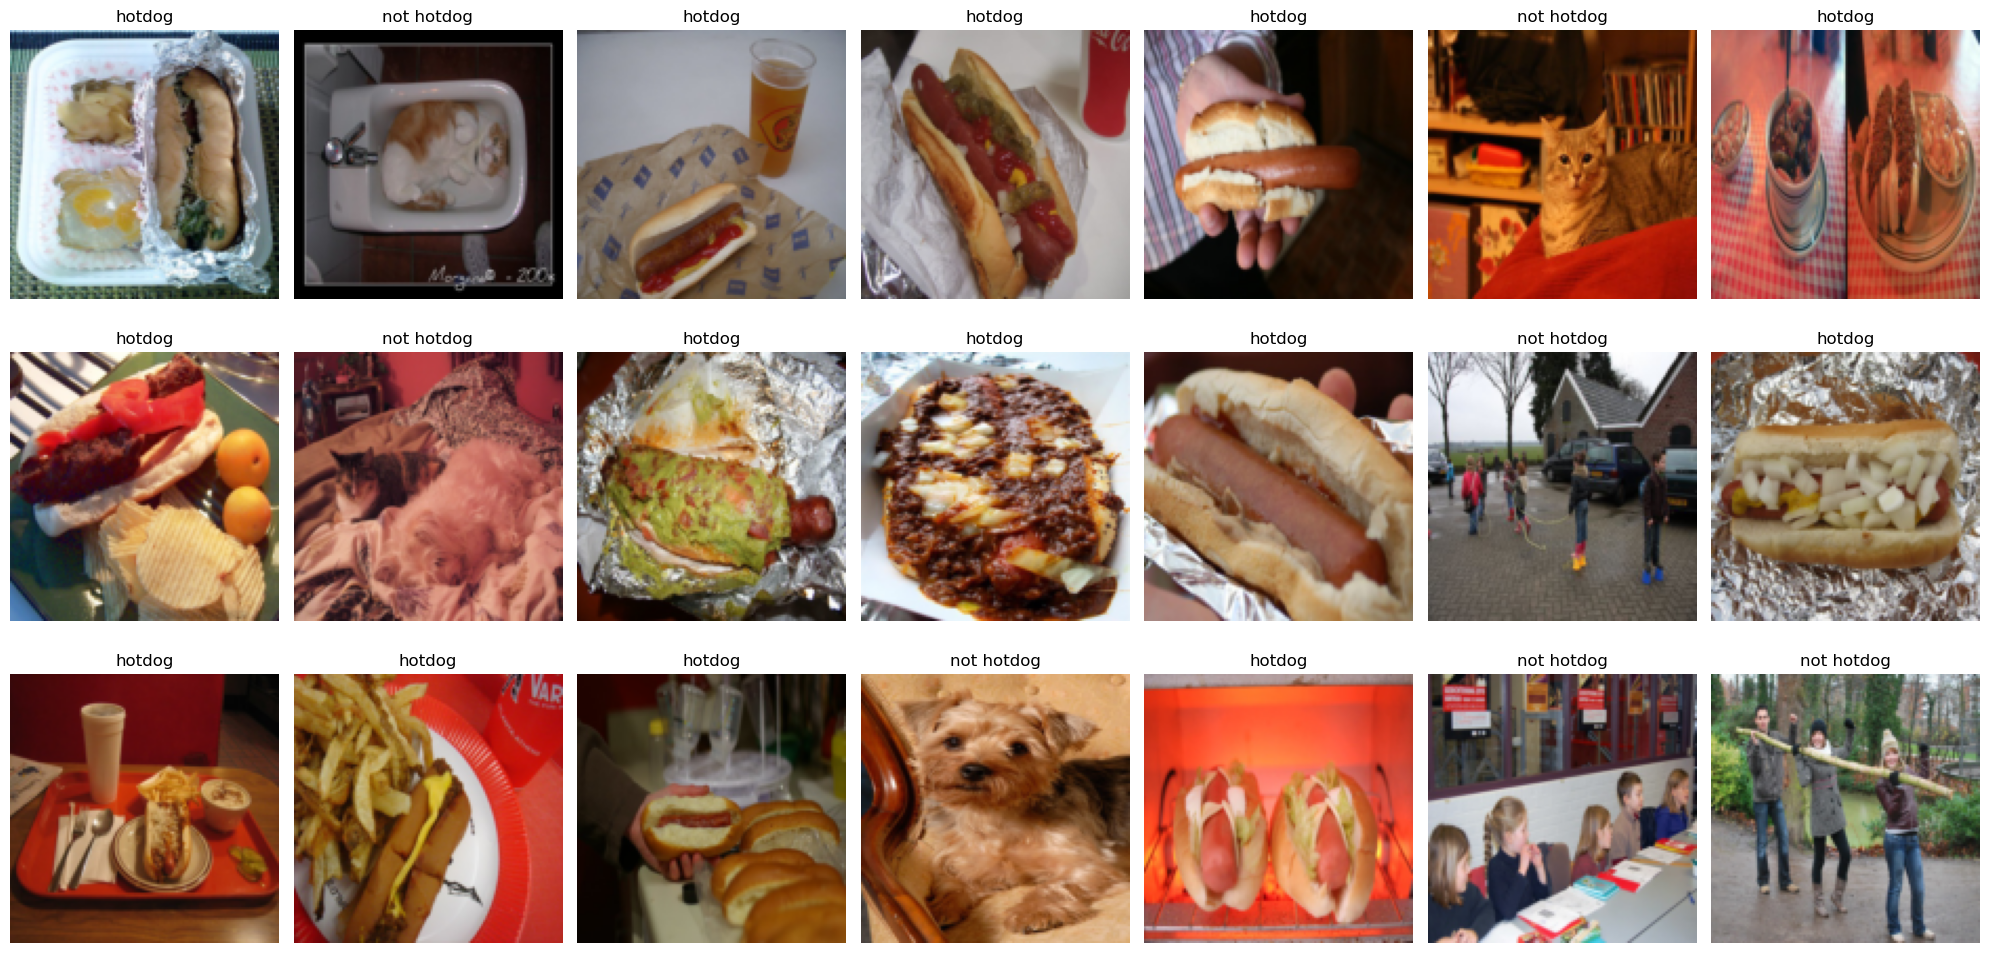

Affichage terminé


In [5]:
plt.figure(figsize=(20,10))
for i in range(min(21, len(images))):  # min() pour éviter l'erreur si moins de 21 images
    plt.subplot(3, 7, i+1)  # 3 lignes 21 images
    
    # Votre méthode corrigée
    img_np = images[i].numpy()
    img_display = np.transpose(img_np, (1, 2, 0))  # Plus de swapaxes
    
    plt.imshow(img_display)
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')

plt.tight_layout()
plt.show()
print('Affichage terminé')

## Affichage 2


Affichage avec la méthode alternative:


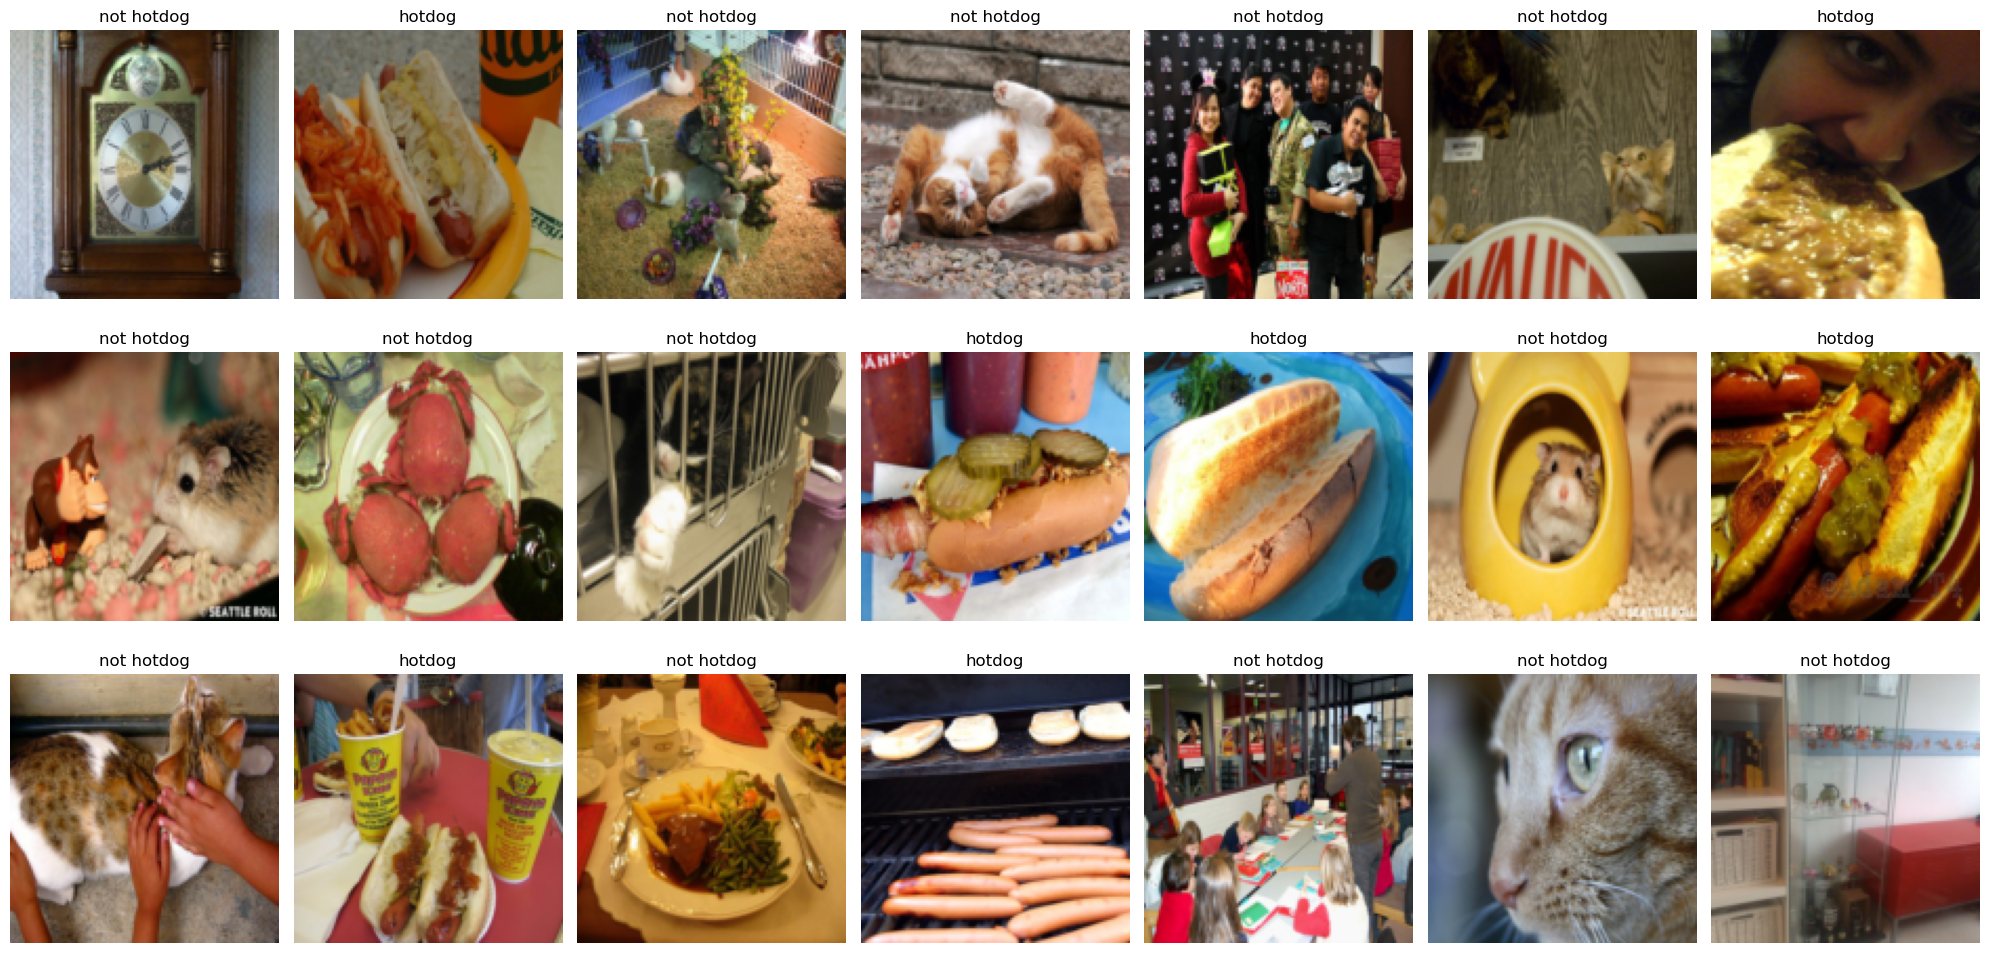

In [6]:
def show_batch(dataloader, num_images=21, figsize=(20,10)):
    """Fonction pour afficher un batch d'images"""
    images, labels = next(iter(dataloader))
    
    cols = 7
    rows = (num_images + cols - 1) // cols
    
    plt.figure(figsize=figsize)
    
    for i in range(min(num_images, len(images))):
        plt.subplot(rows, cols, i+1)
        
        # Conversion PyTorch tensor vers numpy et réarrangement des dimensions
        img = images[i].permute(1, 2, 0)  # (C,H,W) -> (H,W,C)
        img_np = img.numpy()
        
        plt.imshow(img_np)
        plt.title(['hotdog', 'not hotdog'][labels[i].item()])
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Utilisation de la fonction alternative
print("\nAffichage avec la méthode alternative:")
show_batch(train_loader, 21)

## Data Augmentation

In [7]:
size = 128
train_transform = transforms.Compose([
    transforms.Resize((size + 20, size + 20)),  # Légèrement plus grand pour les crops
    transforms.RandomCrop((size, size)),        # Crop aléatoire
    transforms.RandomHorizontalFlip(p=0.5),     # Flip horizontal
    transforms.RandomRotation(degrees=15),      # Rotation légère
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalisation ImageNet
])

test_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


## Modèle CNN

In [8]:
class HotdogCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(HotdogCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)  # Batch normalization
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.relu4 = nn.ReLU(inplace=True)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.pool4(self.relu4(self.bn4(self.conv4(x))))
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        
        return x

## Bloc ResNet

In [21]:
def create_resnet_model(num_classes=2, pretrained=True):
    """Crée un modèle ResNet18 avec transfer learning"""
    model = models.resnet18(pretrained=pretrained)
    
    # Geler les premières couches pour le transfer learning
    if pretrained:
        for param in model.parameters():
            param.requires_grad = False
        
        # Dégeler les dernières couches
        for param in model.layer4.parameters():
            param.requires_grad = True
    
    # Remplacer la dernière couche pour notre problème à 2 classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    return model

## Config + DataLoader

In [22]:
device = torch.device('cpu')  
batch_size = 32  # on réduit pour CPU
learning_rate = 0.001
num_epochs = 10

print(f"Device utilisé: {device}")

trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)

testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Données d'entraînement: {len(trainset)} images")
print(f"Données de test: {len(testset)} images")
print(f"Classes: {trainset.name_to_label}")

Device utilisé: cpu
Données d'entraînement: 2047 images
Données de test: 1862 images
Classes: {'hotdog': 0, 'nothotdog': 1}


## Fonction Train

In [26]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device, scheduler=None):
    """Fonction d'entraînement complète"""
    
    train_losses = []
    train_accuracies = []
    test_accuracies = []
    
    model = model.to(device)

    # Création du writer TensorBoard
    writer = SummaryWriter("runs/lr_example")
    
    global_step = 0  # Compteur pour TensorBoard
    
    for epoch in range(num_epochs):
        # Mode entraînement
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        print(f'\nEpoch [{epoch+1}/{num_epochs}]')
        start_time = time.time()
        
        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            # Loss
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += targets.size(0)
            correct_train += (predicted == targets).sum().item()
            
            # Learning rate courant
            current_lr = optimizer.param_groups[0]['lr']
            
            # Log TensorBoard à chaque batch
            writer.add_scalar("Batch/Loss", loss.item(), global_step)
            writer.add_scalar("Batch/Learning Rate", current_lr, global_step)
            
            global_step += 1
            
            if (batch_idx + 1) % 10 == 0:
                print(f'  Batch [{batch_idx+1}/{len(train_loader)}], '
                      f'Loss: {loss.item():.4f}, LR: {current_lr:.6f}')
        
        # Métriques d'entraînement
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct_train / total_train
        
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Log epoch
        writer.add_scalar("Epoch/Train Loss", epoch_loss, epoch)
        writer.add_scalar("Epoch/Train Accuracy", epoch_acc, epoch)
        writer.add_scalar("Epoch/Learning Rate", current_lr, epoch)
        
        # Évaluation sur le test set
        test_acc = evaluate_model(model, test_loader, device)
        test_accuracies.append(test_acc)
        writer.add_scalar("Epoch/Test Accuracy", test_acc, epoch)
        
        # Scheduler (si fourni)
        if scheduler:
            scheduler.step()
        
        epoch_time = time.time() - start_time
        print(f'  Temps: {epoch_time:.1f}s, Train Loss: {epoch_loss:.4f}, '
              f'Train Acc: {epoch_acc:.2f}%, Test Acc: {test_acc:.2f}%')

    writer.close()    
    return train_losses, train_accuracies, test_accuracies

## Focntion Test

In [27]:
def evaluate_model(model, test_loader, device):
    """Évalue le modèle sur le test set"""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    
    accuracy = 100. * correct / total
    return accuracy

## Boucle itérative

In [28]:
print("="*60)
print("CHOIX DU MODÈLE")
print("1. CNN Custom")
print("2. ResNet18 avec Transfer Learning")
print("="*60)

# Choix du modèle
model_choice = 2

if model_choice == 1:
    print("Création du CNN custom...")
    model = HotdogCNN(num_classes=2)
    print(f"Nombre de paramètres: {sum(p.numel() for p in model.parameters()):,}")
    
elif model_choice == 2:
    print("Création du ResNet18 avec transfer learning...")
    model = create_resnet_model(num_classes=2, pretrained=True)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Paramètres entraînables: {trainable_params:,}/{total_params:,}")

# Critère et optimiseur
criterion = nn.CrossEntropyLoss()  # Inclut automatiquement le softmax
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Entraînement
print(f"\nDébut de l'entraînement sur {device}...")
train_losses, train_accs, test_accs = train_model(
    model, train_loader, test_loader, criterion, optimizer, num_epochs, device
)

CHOIX DU MODÈLE
1. CNN Custom
2. ResNet18 avec Transfer Learning
Création du ResNet18 avec transfer learning...
Paramètres entraînables: 8,394,754/11,177,538

Début de l'entraînement sur cpu...

Epoch [1/10]
  Batch [10/64], Loss: 0.2670, LR: 0.001000
  Batch [20/64], Loss: 0.5873, LR: 0.001000
  Batch [30/64], Loss: 0.2116, LR: 0.001000
  Batch [40/64], Loss: 0.4441, LR: 0.001000
  Batch [50/64], Loss: 0.2554, LR: 0.001000
  Batch [60/64], Loss: 0.2296, LR: 0.001000
  Temps: 80.9s, Train Loss: 0.4120, Train Acc: 83.68%, Test Acc: 87.38%

Epoch [2/10]
  Batch [10/64], Loss: 0.1320, LR: 0.001000
  Batch [20/64], Loss: 0.1500, LR: 0.001000
  Batch [30/64], Loss: 0.1262, LR: 0.001000
  Batch [40/64], Loss: 0.3710, LR: 0.001000
  Batch [50/64], Loss: 0.1922, LR: 0.001000
  Batch [60/64], Loss: 0.3390, LR: 0.001000
  Temps: 79.6s, Train Loss: 0.2410, Train Acc: 89.55%, Test Acc: 89.26%

Epoch [3/10]
  Batch [10/64], Loss: 0.2328, LR: 0.001000
  Batch [20/64], Loss: 0.1383, LR: 0.001000
  Ba

## Visualisation

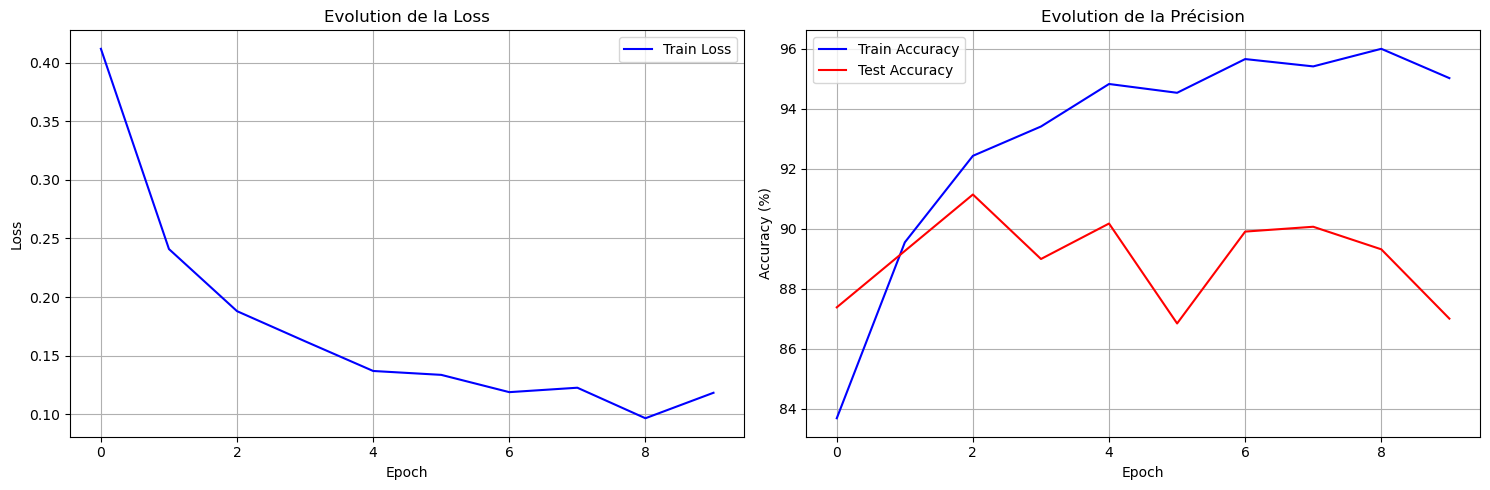

RÉSULTATS FINAUX
Précision finale sur le train: 95.02%
Précision finale sur le test: 87.00%
Modèle sauvegardé dans 'hotdog_model.pth'


In [29]:
def plot_training_history(train_losses, train_accs, test_accs):
    """Affiche l'évolution de l'entraînement"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Perte d'entraînement
    ax1.plot(train_losses, 'b-', label='Train Loss')
    ax1.set_title('Evolution de la Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Précision
    ax2.plot(train_accs, 'b-', label='Train Accuracy')
    ax2.plot(test_accs, 'r-', label='Test Accuracy')
    ax2.set_title('Evolution de la Précision')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(train_losses, train_accs, test_accs)

print("="*60)
print(f"RÉSULTATS FINAUX")
print(f"Précision finale sur le train: {train_accs[-1]:.2f}%")
print(f"Précision finale sur le test: {test_accs[-1]:.2f}%")
print("="*60)

# Sauvegarde du modèle
torch.save(model.state_dict(), 'hotdog_model.pth')
print("Modèle sauvegardé dans 'hotdog_model.pth'")